# 06a Sentinel-1 cross-check

Checks the stage 3 detections with an independent sensor. Sentinel-1 radar sees through cloud, and calm open water is dark in VV backscatter while new fill is bright. All logic lives in `src/reclaim/sar.py`; tables go to `outputs/tables/06_sar_*.csv`.

1. Per year, VV median is split into water and land (`masks`). The threshold is the 95th percentile of VV over stable optical water. A two-class Otsu split (about -13 dB) was tried first and rejected: fresh sand fill sits around -15 dB, between open water (-20 dB) and built land (-7 dB), so Otsu called new fill water for years and confirmed only 9% of the detected area.
2. Each reclamation polygon gets the share of radar-water pixels per year. The stage 3 rule (water in y-2 and y-1, land in y and y+1, never water again) runs on those shares with `sar.min_frac` = 0.5, giving a radar transition year.
3. The radar year is compared with the optical year.
4. The same rule runs per pixel to check the 829 ha that stage 3 cleaning removed, against the pixels it kept.

**What this does and does not show.** Agreement means a detection is not an optical artefact. It is not an accuracy measure; that needs the visual interpretation of stage 6. Floating solar also looks like land to radar and is already masked out in stage 3. Sentinel-1 starts in 2015, so 2016 detections are checked against 2015 only. Radar speckle makes polygons under about 2 ha less reliable.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from reclaim import config, detect, figures, sar
cfg = config.load()
tables, radar = sar.run(cfg)

wrote outputs/tables/06_sar_thresholds.csv
wrote outputs/tables/06_sar_crosscheck.csv
wrote outputs/tables/06_sar_summary.csv
wrote outputs/tables/06_sar_removed.csv


## 1. Radar thresholds

VV threshold (dB) per year. `land_km2` is radar land inside the boundary; it should rise with reclamation. SLA reports a 25.2 km² increase from 2015 to 2025.

In [2]:
tables['06_sar_thresholds']

,year,threshold_db,median_obs,low_obs_pct,land_km2
0,2015,-15.45,42.0,0.0,738.81
1,2016,-17.09,56.0,0.0,745.54
2,2017,-17.00,55.0,0.0,748.96
3,2018,-17.08,60.0,0.0,751.33
4,2019,-16.81,59.0,0.0,752.19
5,2020,-16.83,57.0,0.0,753.56
6,2021,-16.75,61.0,0.0,756.70
7,2022,-16.93,54.0,0.0,762.28
8,2023,-16.77,55.0,0.0,762.81
9,2024,-16.81,50.0,0.0,764.05


## 2. Do radar and optics agree on each polygon?

Area (ha) per detection year and status. `confirmed_pct` counts *same year* and *1 year apart*; the rule itself leaves about a year of timing uncertainty.

In [3]:
s = tables['06_sar_summary']
s

status,year,same year,1 year apart,more than 1 year apart,no transition seen,no radar data,confirmed_pct
0,2016,104.6,1.0,0.0,51.3,0.0,67.3
1,2017,121.5,180.4,19.1,28.7,0.0,86.3
2,2018,52.3,158.7,2.8,110.9,0.0,65.0
3,2019,57.1,168.2,28.5,15.1,0.0,83.8
4,2020,134.7,75.8,6.6,21.6,0.0,88.2
5,2021,122.4,40.6,0.0,29.5,0.0,84.7
6,2022,150.3,22.9,62.5,94.4,0.0,52.5
7,2023,34.1,79.3,17.2,79.9,0.0,53.9
8,2024,71.9,14.9,6.5,48.7,0.0,61.1
9,2025,76.6,56.1,0.6,83.5,0.0,61.2


In [4]:
poly = tables['06_sar_crosscheck']
poly['size'] = np.where(poly.area_ha >= 2, '>= 2 ha', '< 2 ha')
by_size = poly.pivot_table(index='size', columns='status', values='area_ha', aggfunc='sum', fill_value=0).reindex(columns=sar.STATUS, fill_value=0)
by_size['confirmed_pct'] = (by_size['same year'] + by_size['1 year apart']) / by_size.sum(axis=1) * 100
by_size.round(1)

status,same year,1 year apart,more than 1 year apart,no transition seen,no radar data,confirmed_pct
size,,,,,,
< 2 ha,48.6,41.2,15.5,100.7,0,43.6
>= 2 ha,877.0,756.6,128.4,462.8,0,73.4


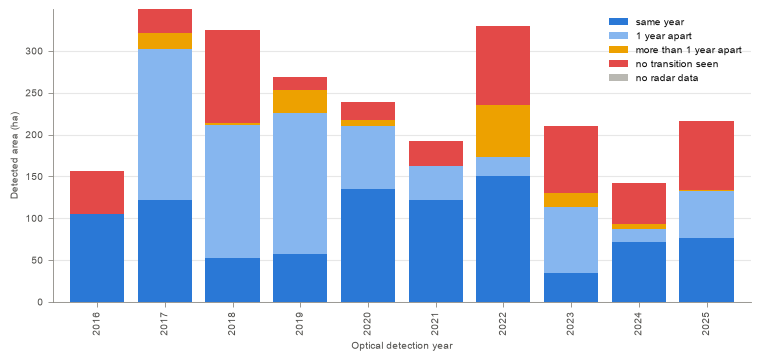

In [5]:
colors = {'same year': '#2a78d6', '1 year apart': '#86b6ef', 'more than 1 year apart': '#eda100',
          'no transition seen': '#e34948', 'no radar data': '#b9b8b2'}
st = s[s.year != 'all'].set_index('year')[sar.STATUS]
ax = st.plot.bar(stacked=True, color=[colors[c] for c in sar.STATUS], figsize=(9, 3.8), width=0.8)
ax.set_ylabel('Detected area (ha)'); ax.set_xlabel('Optical detection year'); ax.legend(bbox_to_anchor=(1, 1), frameon=False)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

Radar year minus optical year, counted in polygons. Negative means radar saw land earlier. The optical composite is the 80th percentile of MNDWI (high tide), so fill on intertidal ground can show up a year late optically.

In [6]:
d = poly[poly.radar_year > 0]
(d.radar_year - d.year).value_counts().sort_index().rename('polygons').to_frame().T

,-7,-4,-3,-2,-1,0,1,2,3,4,5,8
polygons,1,1,1,10,79,103,6,6,9,4,2,1


## 3. Where they disagree

Polygons coloured by status. The disagreeing ones are the first candidates for stage 6 visual interpretation.

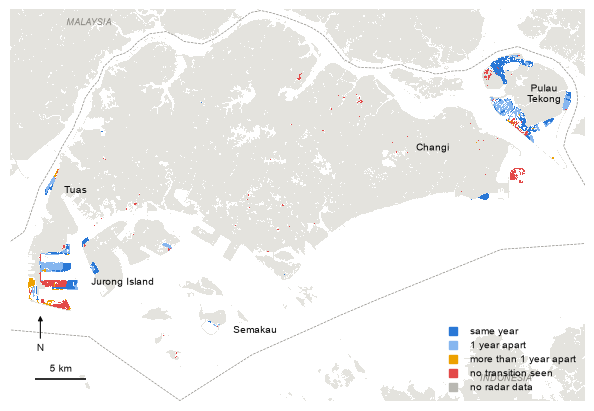

In [7]:
rec = gpd.read_file(detect.OUT).join(poly[['status']])
base = figures.Basemap(cfg)
fig, ax, cax = base.figure(); cax.remove()
base.draw(ax)
for k, c in colors.items():
    sel = rec[rec.status == k]
    if len(sel): sel.plot(ax=ax, color=c, lw=0)
base.annotate(ax)
ax.legend(handles=[plt.Line2D([], [], marker='s', ls='', color=c, label=k) for k, c in colors.items()],
          loc='lower right', frameon=False, fontsize=7)

In [8]:
cols = ['rec_id', 'year', 'radar_year', 'status', 'area_ha'] + [c for c in poly if c.startswith('water_')]
poly[~poly.status.isin(['same year', '1 year apart'])].sort_values('area_ha', ascending=False)[cols].head(15)

,rec_id,year,radar_year,status,area_ha,water_2015,water_2016,water_2017,water_2018,water_2019,water_2020,water_2021,water_2022,water_2023,water_2024,water_2025,water_2026
103,103,2018,0,no transition seen,81.31,0.980,0.971,0.988,0.990,0.987,0.913,0.737,0.349,0.152,0.359,0.706,0.646
231,231,2022,0,no transition seen,71.11,0.981,0.937,0.945,0.972,0.964,0.924,0.602,0.026,0.185,0.513,0.645,0.473
268,268,2023,0,no transition seen,55.32,0.995,0.998,0.994,0.999,0.998,0.995,0.997,0.693,0.030,0.259,0.764,0.823
330,330,2025,0,no transition seen,45.29,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.999,0.869,0.843
233,233,2022,2025,more than 1 year apart,37.20,1.000,1.000,0.878,0.723,0.761,0.968,0.996,0.835,0.854,0.608,0.170,0.143
305,305,2024,0,no transition seen,30.97,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.912,0.889,0.750
105,105,2018,0,no transition seen,25.46,0.769,0.994,0.426,0.005,0.000,0.411,0.700,0.000,0.000,0.000,0.000,0.000
203,203,2021,0,no transition seen,21.10,1.000,0.955,0.945,0.953,0.955,0.719,0.000,0.148,0.516,0.347,0.482,0.234
236,236,2022,2025,more than 1 year apart,16.12,0.978,1.000,1.000,0.965,0.959,0.969,0.991,0.893,0.754,0.604,0.262,0.171
271,271,2023,2025,more than 1 year apart,14.71,1.000,0.997,0.691,0.600,0.996,0.989,0.999,0.821,0.778,0.596,0.132,0.087


## 4. Disagreements up close

VV median before and after the optical year for the largest disagreeing polygons (dark = water). The red outline is the polygon.

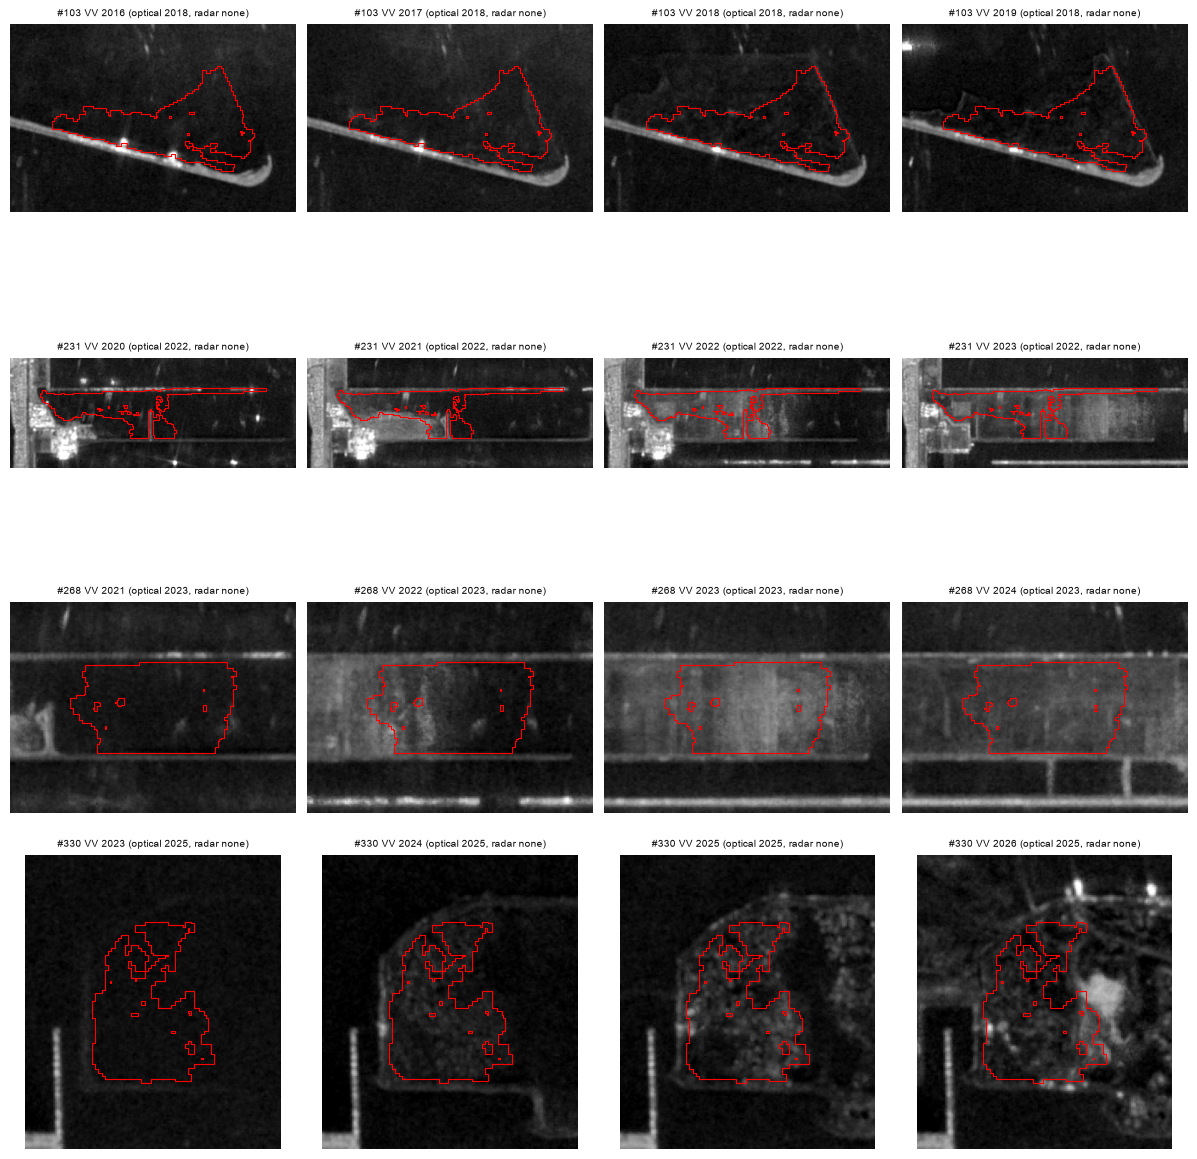

In [9]:
import rasterio
from reclaim.classify import read
bad = poly[~poly.status.isin(['same year', '1 year apart', 'no radar data'])].nlargest(4, 'area_ha')
fig, axes = plt.subplots(len(bad), 4, figsize=(12, 3 * len(bad)), squeeze=False)
for row, (_, p) in zip(axes, bad.iterrows()):
    g = rec.geometry[p.rec_id]
    x0, y0, x1, y1 = g.buffer(400).bounds
    for ax, y in zip(row, [p.year - 2, p.year - 1, p.year, p.year + 1]):
        if y < 2015 or y > 2026: ax.set_axis_off(); continue
        vv, _, prof = read('s1', y)
        t = prof['transform']
        c0, r0 = ~t * (x0, y1); c1, r1 = ~t * (x1, y0)
        crop = vv[int(r0):int(r1), int(c0):int(c1)]
        ax.imshow(crop, cmap='gray', vmin=-22, vmax=0, extent=(x0, x1, y0, y1))
        gpd.GeoSeries([g]).boundary.plot(ax=ax, color='red', lw=0.8)
        ax.set_title(f'#{p.rec_id} VV {y} (optical {p.year}, radar {p.radar_year or "none"})', fontsize=7); ax.set_axis_off()
fig.tight_layout()

## 5. What did stage 3 cleaning remove?

Share of pixels whose radar transition year is within one year of the optical year. If removed pixels were real reclamation they would be confirmed about as often as kept pixels; if they were noise, much less often.

In [10]:
tables['06_sar_removed']

,year,pixels,area_ha,radar_confirmed_pct
0,2016,kept,156.78,37.7
1,2016,removed,144.84,11.4
2,2017,kept,349.65,58.6
3,2017,removed,116.34,21.3
4,2018,kept,324.78,43.1
5,2018,removed,59.87,37.3
6,2019,kept,268.90,51.9
7,2019,removed,53.64,28.8
8,2020,kept,238.73,73.0
9,2020,removed,67.39,25.9
